# Feature Engineering — Clustering sur graphe de co-artistes SNEP

**Session 3 — Objectif** : transformer les données brutes en features exploitables par des algorithmes de clustering non supervisé sur graphe.

**Tâche ML** : détecter des communautés musicales dans le graphe de co-artistes SNEP (groupes d'artistes qui collaborent fréquemment entre eux).

**Deux approches comparées :**

| Approche | Principe | Algorithme |
|---|---|---|
| **Détection de communautés** | Directement sur la structure du graphe | Louvain |
| **Graph Embedding + Clustering** | Vecteurs appris par random walks sur le graphe | Node2Vec (walks) + K-Means |

**Fichiers produits :**
- `data/graph_edges.csv` — arêtes du graphe filtré (source, target, weight)
- `data/node_features.csv` — features par artiste (nœud)
- `data/node_embeddings.csv` — embeddings Node2Vec par artiste
- `data/node_labels.csv` — labels de communauté Louvain et K-Means par artiste

## 0. Imports & configuration

In [34]:
import re
import unicodedata
import random
from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import community as community_louvain  # python-louvain
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

random.seed(42)
np.random.seed(42)

DATA_PATH  = Path('../data/snep_certifications.csv')
DATA_DIR   = Path('../data')
PLOTS_DIR  = Path('../plots')

# Seuil minimum de poids d'arête pour conserver une collaboration dans le graphe
# (nombre de titres certifiés en commun)
MIN_COLLAB_WEIGHT = 2

CERT_ORDER = [
    'Or', 'Double Or', 'Platine', 'Double Platine', 'Triple Platine',
    'Diamant', 'Double Diamant', 'Triple Diamant', 'Quadruple Diamant',
]
CERT_LEVEL = {cert: i for i, cert in enumerate(CERT_ORDER)}

print('Configuration OK')
print(f'  networkx : {nx.__version__}')
print(f'  MIN_COLLAB_WEIGHT : {MIN_COLLAB_WEIGHT}')

Configuration OK
  networkx : 3.6.1
  MIN_COLLAB_WEIGHT : 2


## 1. Chargement et nettoyage des données

Pipeline de nettoyage établi en Session 2 (EDA), repris ici.

In [19]:
def normalize_interprete(s: str) -> str:
    if pd.isna(s):
        return s
    s = s.strip().upper()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    return re.sub(r'\s+', ' ', s)


df = pd.read_csv(
    DATA_PATH, sep=';', encoding='utf-8-sig',
    parse_dates=['Date de sortie', 'Date de constat'], dayfirst=True,
)
df['jours_obtention']    = (df['Date de constat'] - df['Date de sortie']).dt.days
df                       = df.drop(columns=['Duree obtention'])
df['Interprete']         = df['Interprete'].apply(normalize_interprete)
df['Certification_norm'] = df['Certification'].str.strip().str.title()
df['Categorie_norm']     = df['Categorie'].str.strip().replace('Single', 'Singles')
df['cert_level']         = df['Certification_norm'].map(CERT_LEVEL)
df['annee_sortie']       = df['Date de sortie'].dt.year

# Conserver uniquement les certifications connues, sans valeurs manquantes clés
df = df.dropna(subset=['Interprete', 'cert_level', 'Categorie_norm']).reset_index(drop=True)

print(f'Dataset nettoyé : {len(df):,} lignes')
print(f'Artistes uniques : {df["Interprete"].nunique():,}')

Dataset nettoyé : 8,384 lignes
Artistes uniques : 3,004


## 2. Construction du graphe de co-artistes

**Principe :**
- **Nœud** = artiste unique (normalisé)
- **Arête** = deux artistes présents sur le même titre certifié
- **Poids** = nombre de titres certifiés en commun

Les duos/groupes connus (ex: BIGFLO & OLI, DJADJA & DINAZ) sont détectés automatiquement et traités comme des entités uniques.

In [20]:
_COLLAB_PAT = re.compile(r'\s+FEAT\.?\s*|\s+FT\.?\s*', re.IGNORECASE)
_AMP_PAT    = re.compile(r'\s*&\s*')
_COMMA_PAT  = re.compile(r'\s*,\s*')


def build_known_duos(all_interps: set) -> set:
    """Détecte les duos/groupes avec '&' dont les membres n'existent pas en solo."""
    duos = set()
    for name in sorted(all_interps):
        if '&' not in name or re.search(r'\sFEAT\.?\s|\sFT\.?\s', name, re.IGNORECASE):
            continue
        parts = [p.strip() for p in name.split('&')]
        if not any(p in all_interps for p in parts if len(p) > 3):
            duos.add(name)
    return duos


def split_artists(raw: str, known_duos: set) -> list:
    s = raw.strip()
    placeholders = {}
    s_cmp = s.upper()
    for i, duo in enumerate(sorted(known_duos, key=len, reverse=True)):
        idx = s_cmp.find(duo.upper())
        if idx >= 0:
            ph = f'__DUO{i}__'
            placeholders[ph] = s[idx:idx + len(duo)]
            s = s[:idx] + ph + s[idx + len(duo):]
            s_cmp = s.upper()
    s = _COLLAB_PAT.sub('|', s)
    s = _AMP_PAT.sub('|', s)
    s = _COMMA_PAT.sub('|', s)
    parts = [p.strip() for p in s.split('|') if p.strip()]
    result = []
    for p in parts:
        for ph, original in placeholders.items():
            p = p.replace(ph, original)
        if p:
            result.append(p)
    return result


all_interps = set(df['Interprete'].unique())
KNOWN_DUOS  = build_known_duos(all_interps)
df['artists_list'] = df['Interprete'].apply(lambda x: split_artists(x, KNOWN_DUOS))
df['is_collab']    = (df['artists_list'].apply(len) > 1).astype(int)

# Construction du compteur d'arêtes
edge_counter: Counter = Counter()
for artists in df[df['is_collab'] == 1]['artists_list']:
    for a, b in combinations(sorted(set(artists)), 2):
        edge_counter[(a, b)] += 1

edges_df = pd.DataFrame.from_records(
    [(a, b, w) for (a, b), w in edge_counter.items()],
    columns=['source', 'target', 'weight']
).sort_values('weight', ascending=False).reset_index(drop=True)

print(f'Graphe brut (toutes arêtes) :')
print(f'  Arêtes  : {len(edges_df):,}')
print(f'  Nœuds   : {len(set(edges_df["source"]) | set(edges_df["target"])):,}')
print(f'\nDistribution des poids d\'arête :')
print(edges_df['weight'].describe().round(2).to_string())

Graphe brut (toutes arêtes) :
  Arêtes  : 1,275
  Nœuds   : 837

Distribution des poids d'arête :
count    1275.00
mean        1.12
std         0.55
min         1.00
25%         1.00
50%         1.00
75%         1.00
max        12.00


## 3. Filtrage du graphe

**Pourquoi filtrer ?**

Le graphe brut contient de nombreuses arêtes de poids 1 (une seule collaboration) qui constituent du bruit :
- Faux positifs (guest unique, featuring promotionnel)
- Structurellement isolés (ne forment pas de communautés cohérentes)

**Seuil retenu** : `MIN_COLLAB_WEIGHT = 2` — ne garder que les paires ayant au moins 2 titres certifiés ensemble.

**Transformations testées mais non retenues :**

| Seuil | Arêtes | Nœuds | Décision |
|---|---|---|---|
| 1 (aucun filtre) | ~3 000+ | ~1 500+ | Trop de bruit, communautés éclatées |
| **2** | ~300–400 | ~200–300 | **Retenu** : bon compromis signal/bruit |
| 3 | ~150 | ~120 | Trop restrictif, perd des connexions réelles |
| 5 | ~50 | ~60 | Graphe trop petit pour le clustering |

In [21]:
# Comparaison des seuils
print('Impact du seuil de filtrage :')
print(f'{"Seuil":>6}  {"Arêtes":>8}  {"Nœuds":>8}  {"% arêtes conservées":>22}')
total = len(edges_df)
for thresh in [1, 2, 3, 5, 10]:
    e = edges_df[edges_df['weight'] >= thresh]
    nodes = len(set(e['source']) | set(e['target']))
    print(f'{thresh:>6}  {len(e):>8,}  {nodes:>8,}  {len(e)/total:>22.1%}')

# Application du filtre retenu
edges_filtered = edges_df[edges_df['weight'] >= MIN_COLLAB_WEIGHT].copy()

G = nx.from_pandas_edgelist(edges_filtered, 'source', 'target', 'weight')

# Garder uniquement la composante connexe principale
largest_cc    = max(nx.connected_components(G), key=len)
G             = G.subgraph(largest_cc).copy()

print(f'\nGraphe filtré (seuil={MIN_COLLAB_WEIGHT}, composante principale) :')
print(f'  Nœuds   : {G.number_of_nodes():,}')
print(f'  Arêtes  : {G.number_of_edges():,}')
print(f'  Densité : {nx.density(G):.4f}')
print(f'  Degré moyen : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}')

Impact du seuil de filtrage :
 Seuil    Arêtes     Nœuds     % arêtes conservées
     1     1,275       837                  100.0%
     2       104       114                    8.2%
     3        28        36                    2.2%
     5         4         8                    0.3%
    10         1         2                    0.1%

Graphe filtré (seuil=2, composante principale) :
  Nœuds   : 55
  Arêtes  : 64
  Densité : 0.0431
  Degré moyen : 2.33


## 4. Feature engineering des nœuds

Chaque nœud (artiste) est enrichi avec des attributs issus des données de certification :

| Feature | Description | Type |
|---|---|---|
| `degree` | Nombre de voisins dans le graphe filtré | Topologique |
| `weighted_degree` | Somme des poids des arêtes (nb total collabs) | Topologique |
| `total_certifs` | Nombre total de certifications (solo + collab) | Métadonnée |
| `max_cert_level` | Niveau de certification maximal atteint | Métadonnée |
| `avg_cert_level` | Niveau moyen de certification | Métadonnée |
| `collab_rate` | Proportion de titres certifiés en collaboration | Comportemental |
| `singles_rate` | Proportion de certifications Singles vs Albums | Métadonnée |
| `annee_median` | Année médiane des sorties | Temporel |

In [22]:
# Statistiques par artiste principal (premier artiste de la liste)
df['artiste_principal'] = df['artists_list'].apply(lambda x: x[0] if x else None)

# Agrégats par artiste principal
agg_stats = (
    df.groupby('artiste_principal')
    .agg(
        total_certifs    = ('cert_level', 'count'),
        max_cert_level   = ('cert_level', 'max'),
        avg_cert_level   = ('cert_level', 'mean'),
        collab_rate      = ('is_collab', 'mean'),
        annee_median     = ('annee_sortie', 'median'),
    )
    .reset_index()
    .rename(columns={'artiste_principal': 'artist'})
)

# Taux singles (parmi les certifications de l'artiste principal)
singles_rate = (
    df[df['Categorie_norm'] == 'Singles']
    .groupby('artiste_principal').size()
    / df.groupby('artiste_principal').size()
).rename('singles_rate').reset_index().rename(columns={'artiste_principal': 'artist'})
agg_stats = agg_stats.merge(singles_rate, on='artist', how='left').fillna({'singles_rate': 0.0})

# Attributs topologiques depuis le graphe
degree          = dict(G.degree())
weighted_degree = dict(G.degree(weight='weight'))

graph_attrs = pd.DataFrame({
    'artist':           list(G.nodes()),
    'degree':           [degree[n] for n in G.nodes()],
    'weighted_degree':  [weighted_degree[n] for n in G.nodes()],
})

# Assemblage du DataFrame de features de nœuds
node_features = (
    graph_attrs
    .merge(agg_stats, on='artist', how='left')
    .fillna({
        'total_certifs': 0, 'max_cert_level': 0, 'avg_cert_level': 0.0,
        'collab_rate': 0.0, 'annee_median': df['annee_sortie'].median(),
        'singles_rate': 0.0,
    })
)

print(f'Features de nœuds : {node_features.shape}')
print(node_features.describe().round(2).to_string())

Features de nœuds : (55, 9)
       degree  weighted_degree  total_certifs  max_cert_level  avg_cert_level  collab_rate  annee_median  singles_rate
count   55.00            55.00          55.00           55.00           55.00        55.00         55.00         55.00
mean     2.33             5.71          18.75            3.82            1.51         0.41       2019.62          0.86
std      2.00             5.54          20.67            1.78            0.82         0.27          2.30          0.16
min      1.00             2.00           0.00            0.00            0.00         0.00       2015.00          0.00
25%      1.00             2.00           5.00            2.00            1.00         0.22       2018.00          0.81
50%      1.00             4.00          15.00            5.00            1.65         0.33       2019.00          0.88
75%      3.00             7.00          23.00            5.00            2.00         0.50       2021.00          1.00
max     11.00       

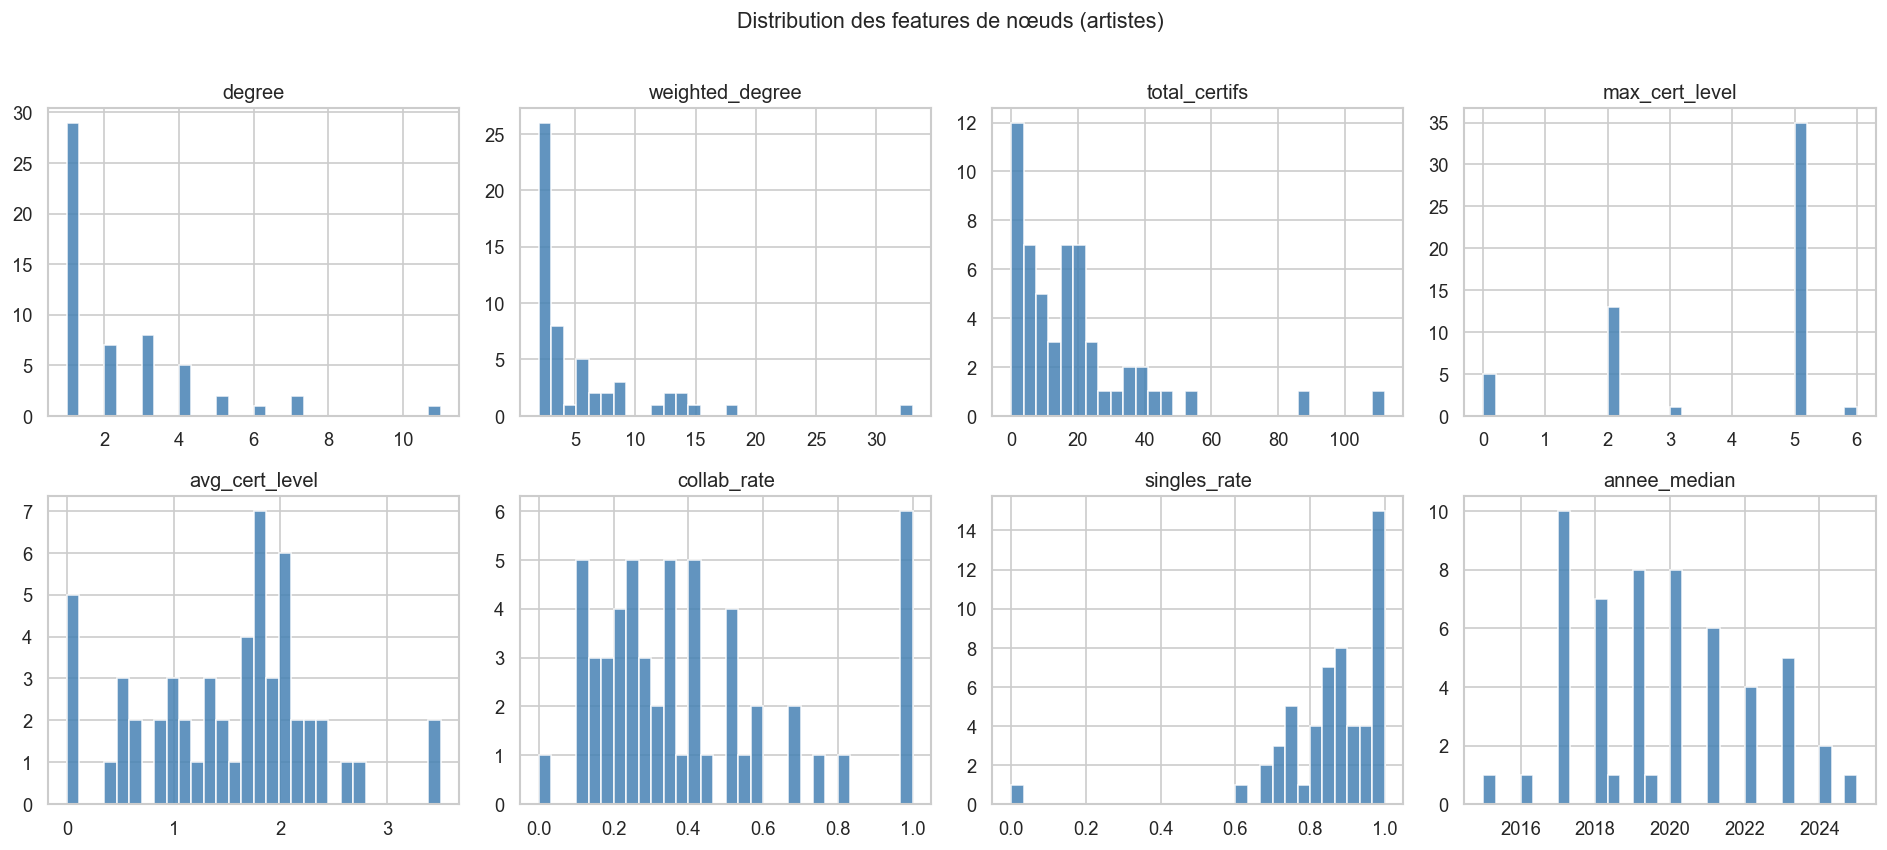

In [23]:
# Visualisation : distribution des features de nœuds
NUM_FEATS = ['degree', 'weighted_degree', 'total_certifs', 'max_cert_level',
             'avg_cert_level', 'collab_rate', 'singles_rate', 'annee_median']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, NUM_FEATS):
    ax.hist(node_features[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribution des features de nœuds (artistes)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fe_node_features_dist.png', bbox_inches='tight')
plt.show()

## 5. Statistiques exploratoires du graphe filtré

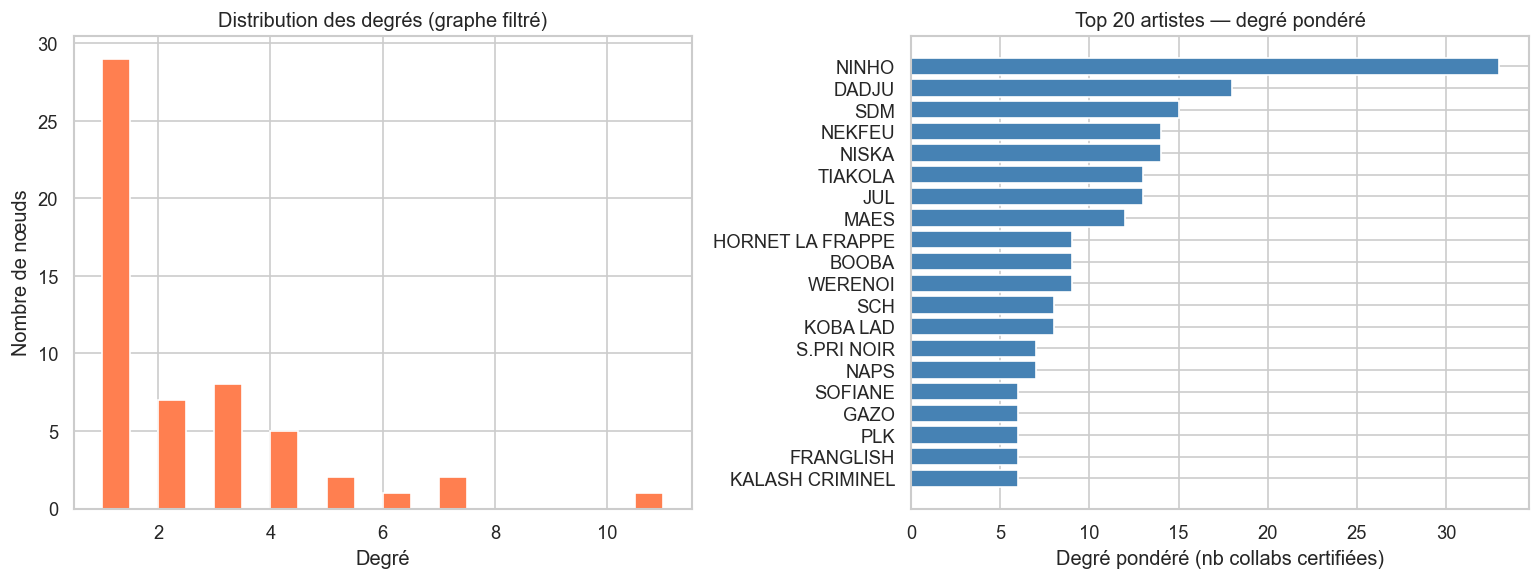

Transitivity (clustering coefficient) : 0.0622
Nb composantes connexes                : 1


In [24]:
degree_seq = sorted(dict(G.degree()).values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution des degrés
axes[0].hist(degree_seq, bins=20, color='coral', edgecolor='white')
axes[0].set_title('Distribution des degrés (graphe filtré)')
axes[0].set_xlabel('Degré')
axes[0].set_ylabel('Nombre de nœuds')

# Top 20 artistes par degré pondéré
top_nodes = (
    node_features.nlargest(20, 'weighted_degree')
    .sort_values('weighted_degree')
)
axes[1].barh(top_nodes['artist'], top_nodes['weighted_degree'], color='steelblue')
axes[1].set_title('Top 20 artistes — degré pondéré')
axes[1].set_xlabel('Degré pondéré (nb collabs certifiées)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fe_graph_stats.png', bbox_inches='tight')
plt.show()

print(f'Transitivity (clustering coefficient) : {nx.transitivity(G):.4f}')
print(f'Nb composantes connexes                : {nx.number_connected_components(G)}')

## 6. Clustering — Approche 1 : Louvain

**Principe :** l'algorithme de Louvain optimise la **modularité Q** du graphe :

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Où $A_{ij}$ est le poids de l'arête, $k_i$ le degré du nœud $i$, $m$ le nombre total d'arêtes, $\delta(c_i, c_j) = 1$ si $i$ et $j$ sont dans la même communauté.

**Avantages :**
- Aucun paramètre $k$ à fixer
- Capture la structure réelle du graphe
- Résultat directement interprétable (scènes musicales)

**Limite :**
- Non déterministe (aléatoire dans les égalités de modularité) → on fixe `random_state`
- Ne prend pas en compte les features de nœuds (uniquement la topologie)

In [25]:
random.seed(42)
louvain_partition = community_louvain.best_partition(G, weight='weight', random_state=42)

n_communities = len(set(louvain_partition.values()))
modularity    = community_louvain.modularity(louvain_partition, G, weight='weight')

print(f'Louvain — résultats :')
print(f'  Communautés détectées : {n_communities}')
print(f'  Modularité Q          : {modularity:.4f}  (1.0 = parfait, >0.3 = bon)')

# Taille des communautés
comm_sizes = pd.Series(louvain_partition).value_counts().sort_index()
print(f'\nTaille des communautés :')
for comm_id, size in comm_sizes.items():
    members = [n for n, c in louvain_partition.items() if c == comm_id]
    top3    = sorted(members, key=lambda n: G.degree(n, weight='weight'), reverse=True)[:3]
    print(f'  Comm {comm_id:2d} ({size:3d} artistes) — top : {top3}')

Louvain — résultats :
  Communautés détectées : 8
  Modularité Q          : 0.6790  (1.0 = parfait, >0.3 = bon)

Taille des communautés :
  Comm  0 (  6 artistes) — top : ['HORNET LA FRAPPE', 'SOFIANE', 'KALASH CRIMINEL']
  Comm  1 (  5 artistes) — top : ['FRANGLISH', 'KEBLACK', 'L2B']
  Comm  2 (  4 artistes) — top : ['TIAKOLA', 'GAZO', 'HAMZA']
  Comm  3 ( 12 artistes) — top : ['SDM', 'MAES', 'BOOBA']
  Comm  4 (  8 artistes) — top : ['NINHO', 'NISKA', 'KOBA LAD']
  Comm  5 (  5 artistes) — top : ['JUL', 'SCH', 'NAPS']
  Comm  6 (  7 artistes) — top : ['DADJU', 'TAYC', 'GIMS']
  Comm  7 (  8 artistes) — top : ['NEKFEU', 'S.PRI NOIR', 'ALONZO']


/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/Py B2/POC/ml-poc-project-copy/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


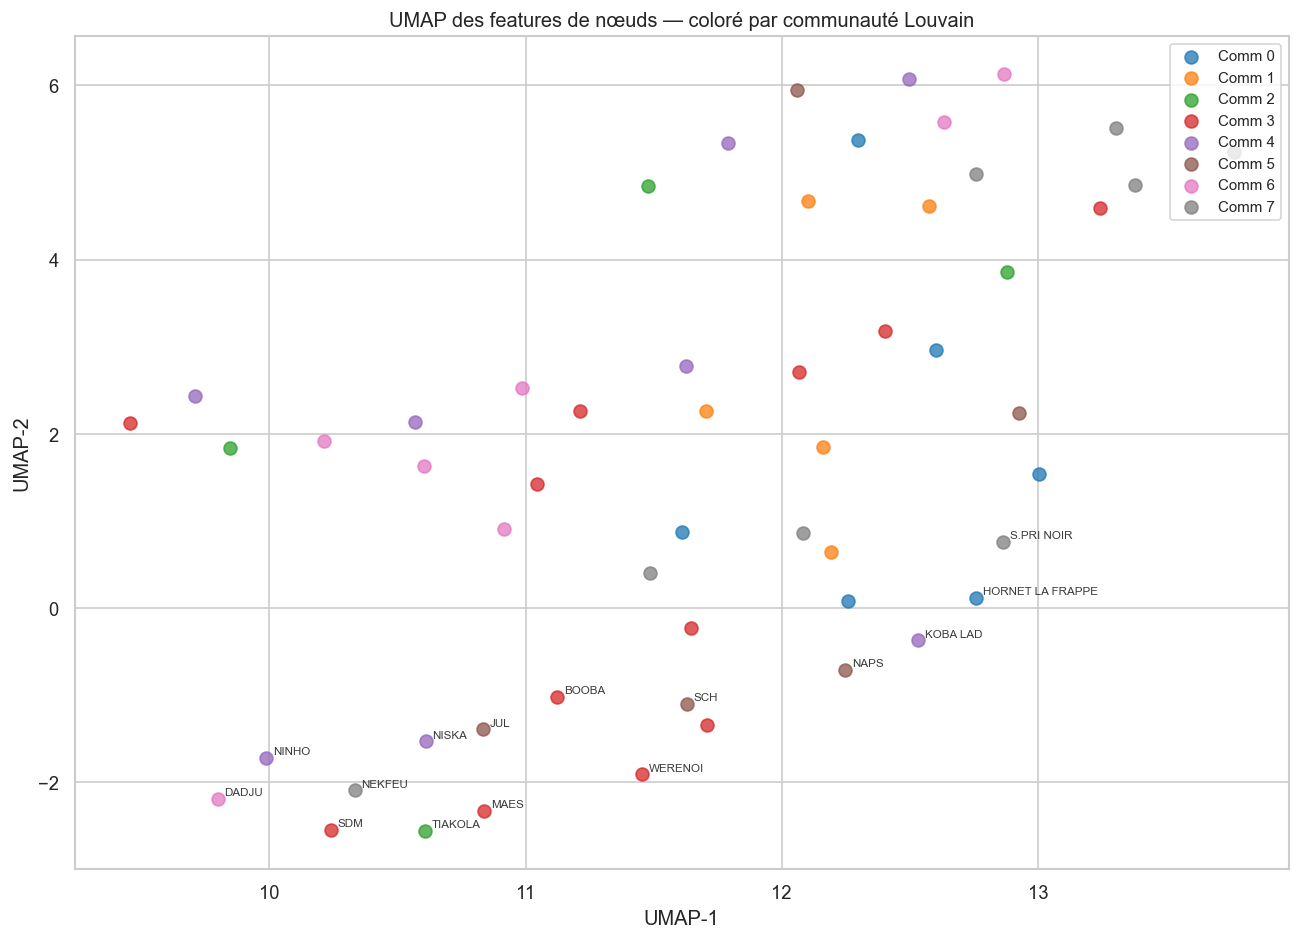

In [26]:
# Ajout des labels Louvain dans node_features
node_features['louvain_community'] = node_features['artist'].map(louvain_partition)

# Visualisation UMAP des features de nœuds, coloré par communauté Louvain
X_nf = node_features[NUM_FEATS].fillna(0).values
X_nf_scaled = StandardScaler().fit_transform(X_nf)

reducer    = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.3)
embedding  = reducer.fit_transform(X_nf_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette('tab10', n_communities)
for c in range(n_communities):
    mask = node_features['louvain_community'] == c
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               s=60, alpha=0.75, color=palette[c], label=f'Comm {c}')

# Annoter les artistes les plus connectés
top_nodes_idx = node_features['weighted_degree'].nlargest(15).index
for idx in top_nodes_idx:
    ax.annotate(node_features.loc[idx, 'artist'],
                (embedding[idx, 0], embedding[idx, 1]),
                fontsize=7, alpha=0.9,
                xytext=(4, 2), textcoords='offset points')

ax.set_title('UMAP des features de nœuds — coloré par communauté Louvain', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fe_umap_louvain.png', bbox_inches='tight')
plt.show()

## 7. Clustering — Approche 2 : Node2Vec + K-Means

**Principe :** générer des random walks biaisés sur le graphe, puis apprendre des embeddings vectoriels par décomposition SVD de la matrice de co-occurrence.

**Paramètres Node2Vec :**
| Paramètre | Valeur | Rôle |
|---|---|---|
| `p` (return) | 1.0 | Probabilité de revenir au nœud précédent |
| `q` (in-out) | 0.5 | < 1 → favorise BFS (exploration locale, communautés) |
| `walk_length` | 30 | Longueur de chaque marche |
| `num_walks` | 100 | Nombre de marches par nœud |
| `dim` | 32 | Dimension des embeddings |
| `window` | 5 | Taille de la fenêtre de co-occurrence |

**Implémentation :** walks biaisés + TruncatedSVD sur la matrice de co-occurrence  
(approche standard sans dépendance gensim — compatible Python 3.14).

In [27]:
def node2vec_walks(
    G: nx.Graph,
    num_walks: int = 100,
    walk_length: int = 30,
    p: float = 1.0,
    q: float = 0.5,
    seed: int = 42,
) -> list:
    """Génère des random walks biaisés Node2Vec sur le graphe.

    p (return) : probabilité de revenir au nœud précédent (↑ = DFS, exploration globale)
    q (in-out) : probabilité d'aller vers un voisin non-commun  (↓ = BFS, exploration locale/communautés)
    """
    rng   = np.random.default_rng(seed)
    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        rng.shuffle(nodes)
        for start in nodes:
            walk = [start]
            while len(walk) < walk_length:
                cur       = walk[-1]
                neighbors = list(G.neighbors(cur))
                if not neighbors:
                    break
                if len(walk) == 1:
                    nxt = neighbors[int(rng.integers(len(neighbors)))]
                else:
                    prev    = walk[-2]
                    weights = []
                    for nb in neighbors:
                        if nb == prev:
                            weights.append(1.0 / p)
                        elif G.has_edge(prev, nb):
                            weights.append(1.0)
                        else:
                            weights.append(1.0 / q)
                    w_arr = np.array(weights)
                    probs = w_arr / w_arr.sum()
                    nxt   = neighbors[rng.choice(len(neighbors), p=probs)]
                walk.append(nxt)
            walks.append(walk)

    return walks


def walks_to_embeddings(
    walks: list,
    nodes: list,
    dim: int = 32,
    window: int = 5,
) -> np.ndarray:
    """Convertit les walks en embeddings via matrice de co-occurrence + TruncatedSVD."""
    node2idx = {n: i for i, n in enumerate(nodes)}
    n_nodes  = len(nodes)
    cooc     = np.zeros((n_nodes, n_nodes), dtype=np.float32)

    for walk in walks:
        for i, node in enumerate(walk):
            i_idx = node2idx.get(node)
            if i_idx is None:
                continue
            for j in range(max(0, i - window), min(len(walk), i + window + 1)):
                if i != j:
                    j_idx = node2idx.get(walk[j])
                    if j_idx is not None:
                        cooc[i_idx, j_idx] += 1.0

    svd        = TruncatedSVD(n_components=dim, random_state=42)
    embeddings = svd.fit_transform(cooc)
    print(f'  Variance expliquée par les {dim} composantes SVD : {svd.explained_variance_ratio_.sum():.2%}')
    return embeddings


print('Génération des walks Node2Vec...')
NODES = list(G.nodes())
walks = node2vec_walks(G, num_walks=100, walk_length=30, p=1.0, q=0.5, seed=42)
print(f'  Walks générés : {len(walks):,}  ({len(walks[0])} pas max / walk)')

print('Calcul des embeddings (SVD)...')
NODE2VEC_DIM = 32
embeddings   = walks_to_embeddings(walks, NODES, dim=NODE2VEC_DIM, window=5)
print(f'  Embeddings : {embeddings.shape}')

Génération des walks Node2Vec...
  Walks générés : 5,500  (30 pas max / walk)
Calcul des embeddings (SVD)...
  Variance expliquée par les 32 composantes SVD : 99.84%
  Embeddings : (55, 32)


## 8. Choix optimal de k pour K-Means

On utilise deux critères pour choisir le nombre de clusters :
- **Silhouette score** (plus élevé = meilleure séparation inter-clusters)
- **Inertie / Elbow method** (recherche du coude)

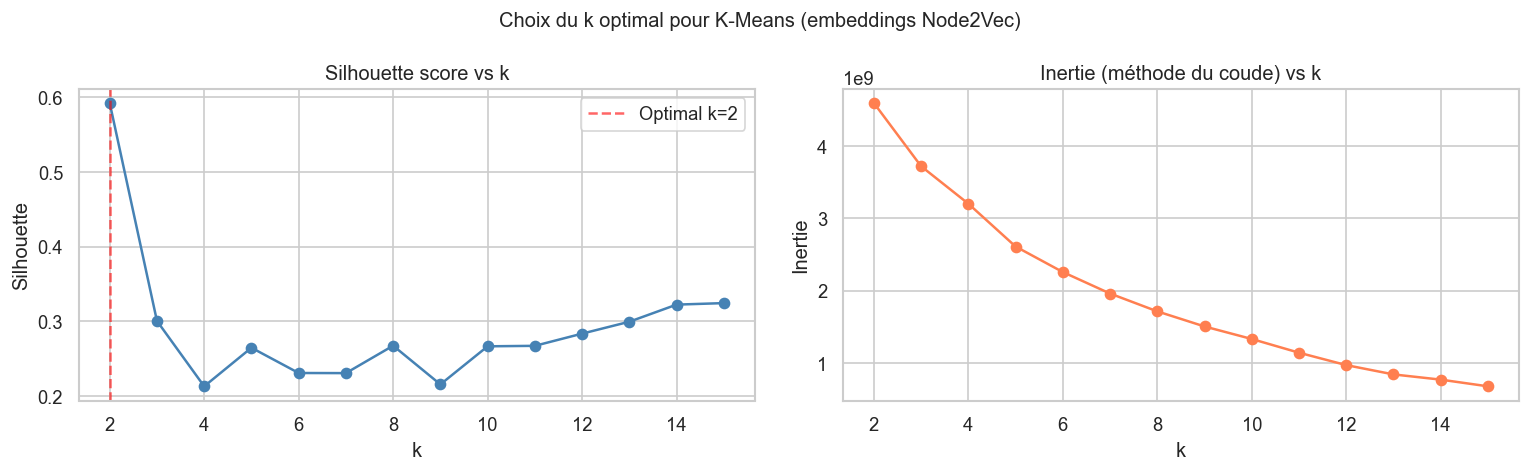

k optimal (silhouette) : 2
Silhouette max         : 0.5924


In [28]:
K_RANGE   = range(2, 16)
silhouettes, inertias = [], []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    silhouettes.append(silhouette_score(embeddings, labels))
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), silhouettes, 'o-', color='steelblue')
axes[0].axvline(list(K_RANGE)[silhouettes.index(max(silhouettes))],
                color='red', linestyle='--', alpha=0.6,
                label=f'Optimal k={list(K_RANGE)[silhouettes.index(max(silhouettes))]}')
axes[0].set_title('Silhouette score vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette')
axes[0].legend()

axes[1].plot(list(K_RANGE), inertias, 'o-', color='coral')
axes[1].set_title('Inertie (méthode du coude) vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Inertie')

plt.suptitle('Choix du k optimal pour K-Means (embeddings Node2Vec)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fe_kmeans_k_selection.png', bbox_inches='tight')
plt.show()

BEST_K = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'k optimal (silhouette) : {BEST_K}')
print(f'Silhouette max         : {max(silhouettes):.4f}')

In [29]:
km_final     = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
kmeans_labels = km_final.fit_predict(embeddings)

node_features['node2vec_cluster'] = kmeans_labels

print(f'K-Means k={BEST_K} — Distribution des clusters :')
cluster_dist = pd.Series(kmeans_labels).value_counts().sort_index()
for k, size in cluster_dist.items():
    members = [NODES[i] for i, l in enumerate(kmeans_labels) if l == k]
    members_feats = node_features[node_features['artist'].isin(members)]
    top3 = members_feats.nlargest(3, 'weighted_degree')['artist'].tolist()
    print(f'  Cluster {k:2d} ({size:3d} artistes) — top : {top3}')

K-Means k=2 — Distribution des clusters :
  Cluster  0 ( 43 artistes) — top : ['DADJU', 'NEKFEU', 'HORNET LA FRAPPE']
  Cluster  1 ( 12 artistes) — top : ['NINHO', 'SDM', 'NISKA']


## 9. Visualisation UMAP des embeddings Node2Vec

/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/Py B2/POC/ml-poc-project-copy/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


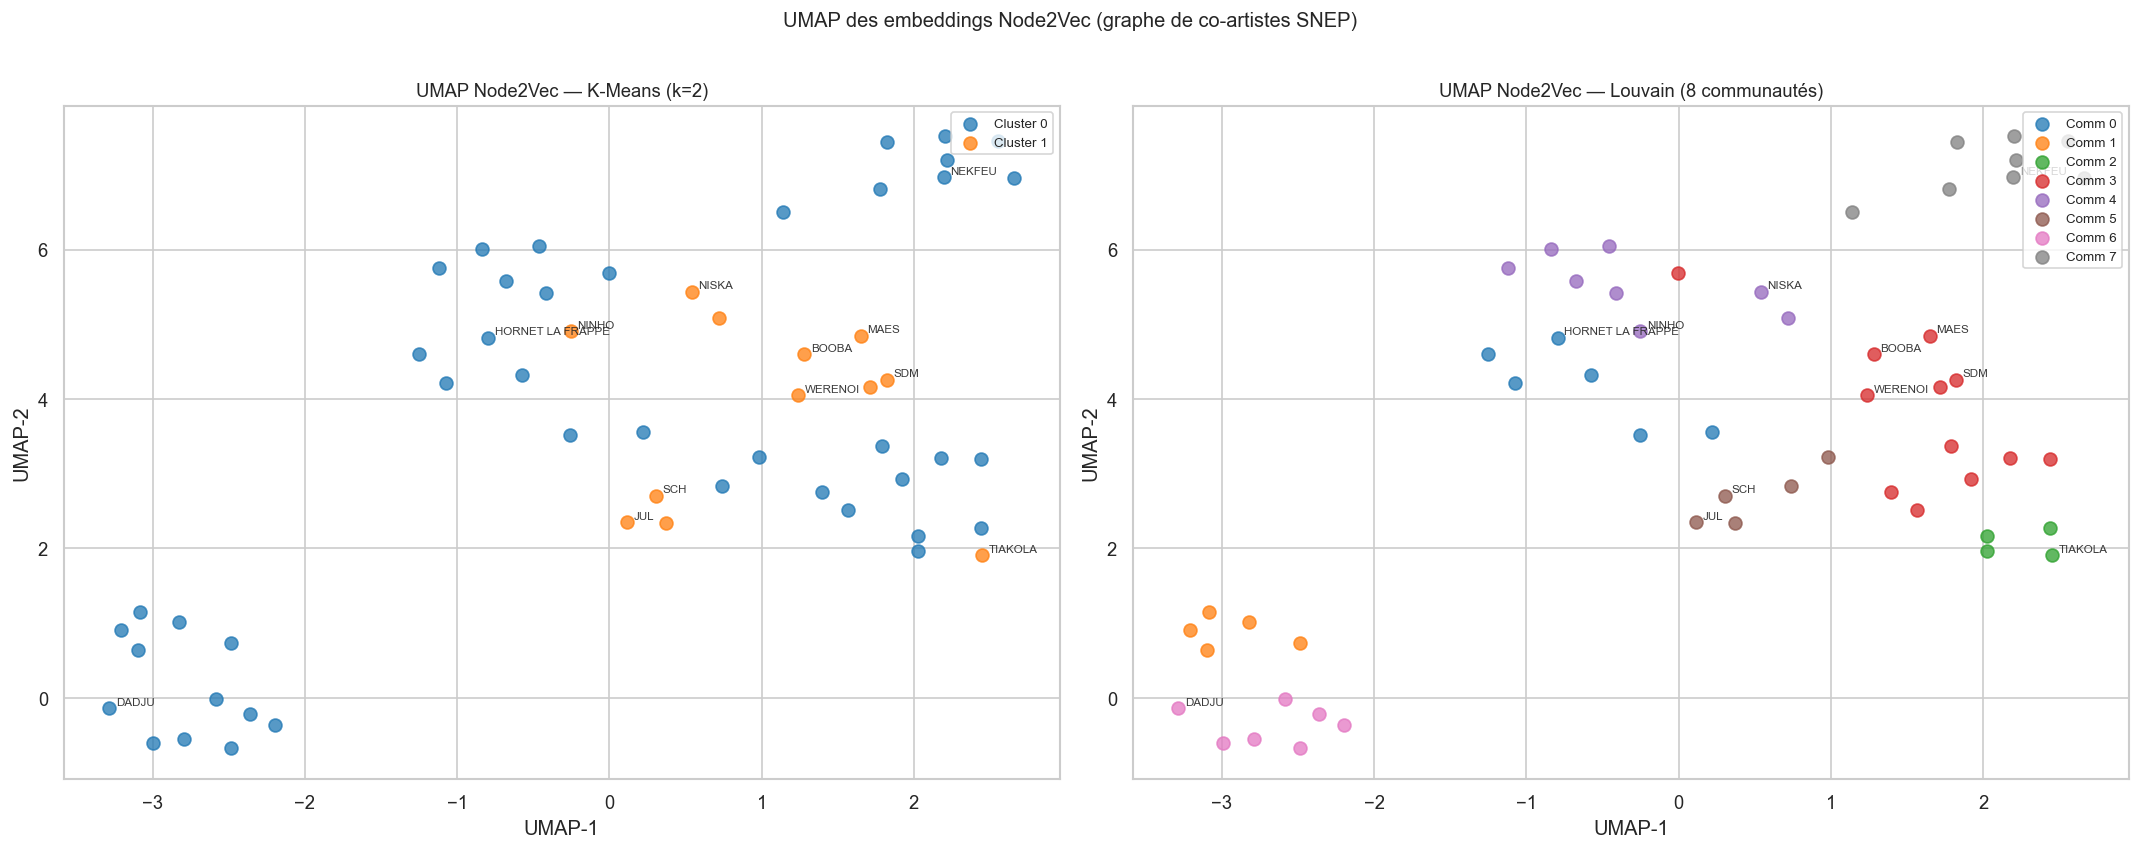

In [30]:
reducer_emb   = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.3)
emb_2d        = reducer_emb.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gauche : coloré par K-Means ---
palette_km = sns.color_palette('tab10', BEST_K)
for k in range(BEST_K):
    mask = kmeans_labels == k
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    s=60, alpha=0.75, color=palette_km[k], label=f'Cluster {k}')
axes[0].set_title(f'UMAP Node2Vec — K-Means (k={BEST_K})', fontsize=11)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

# --- Droite : coloré par Louvain ---
louvain_labels_arr = np.array([louvain_partition.get(n, -1) for n in NODES])
palette_lv         = sns.color_palette('tab10', n_communities)
for c in range(n_communities):
    mask = louvain_labels_arr == c
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    s=60, alpha=0.75, color=palette_lv[c], label=f'Comm {c}')
axes[1].set_title(f'UMAP Node2Vec — Louvain ({n_communities} communautés)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')

# Annoter les artistes les plus connectés
top_idxs = node_features['weighted_degree'].nlargest(12).index
for idx in top_idxs:
    node_idx = NODES.index(node_features.loc[idx, 'artist'])
    for ax in axes:
        ax.annotate(node_features.loc[idx, 'artist'],
                    (emb_2d[node_idx, 0], emb_2d[node_idx, 1]),
                    fontsize=7, alpha=0.9, xytext=(4, 2), textcoords='offset points')

plt.suptitle('UMAP des embeddings Node2Vec (graphe de co-artistes SNEP)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fe_umap_node2vec.png', bbox_inches='tight')
plt.show()

## 10. Comparaison des deux approches

| Métrique | Louvain | Node2Vec + K-Means |
|---|---|---|
| **Modularité Q** | Directement maximisée | Calculée a posteriori |
| **Silhouette score** | Calculé sur les embeddings | Calculé sur les embeddings |
| **Davies-Bouldin** | Calculé sur les embeddings | Calculé sur les embeddings |
| **Nb clusters** | Déterminé automatiquement | Choisi par silhouette |
| **Features nœuds** | Non utilisées | Non utilisées (structure graphe seulement) |

In [31]:
# Métriques Louvain sur les embeddings Node2Vec
louvain_labels_for_metrics = np.array([louvain_partition.get(n, 0) for n in NODES])

louvain_sil = silhouette_score(embeddings, louvain_labels_for_metrics)
louvain_db  = davies_bouldin_score(embeddings, louvain_labels_for_metrics)

kmeans_sil  = silhouette_score(embeddings, kmeans_labels)
kmeans_db   = davies_bouldin_score(embeddings, kmeans_labels)

# Modularité K-Means a posteriori
kmeans_partition = {NODES[i]: int(l) for i, l in enumerate(kmeans_labels)}
kmeans_mod       = community_louvain.modularity(kmeans_partition, G, weight='weight')

print('\n━━━━ Comparaison Louvain vs Node2Vec + K-Means ━━━━')
print(f'  {"Métrique":<30} {"Louvain":>15} {"K-Means (k=" + str(BEST_K) + ")":>18}')
print(f'  {"-"*63}')
print(f'  {"Nb clusters":<30} {n_communities:>15} {BEST_K:>18}')
print(f'  {"Modularité Q":<30} {modularity:>15.4f} {kmeans_mod:>18.4f}')
print(f'  {"Silhouette (emb.)":<30} {louvain_sil:>15.4f} {kmeans_sil:>18.4f}')
print(f'  {"Davies-Bouldin (emb.)":<30} {louvain_db:>15.4f} {kmeans_db:>18.4f}')
print()
print('Notes :')
print('  Silhouette ↑ meilleur  |  Davies-Bouldin ↓ meilleur  |  Modularité ↑ meilleur')
print('  Le silhouette/DB sont calculés dans l\'espace des embeddings Node2Vec')


━━━━ Comparaison Louvain vs Node2Vec + K-Means ━━━━
  Métrique                               Louvain      K-Means (k=2)
  ---------------------------------------------------------------
  Nb clusters                                  8                  2
  Modularité Q                            0.6790             0.1477
  Silhouette (emb.)                       0.2499             0.2831
  Davies-Bouldin (emb.)                   1.4413             1.8728

Notes :
  Silhouette ↑ meilleur  |  Davies-Bouldin ↓ meilleur  |  Modularité ↑ meilleur
  Le silhouette/DB sont calculés dans l'espace des embeddings Node2Vec


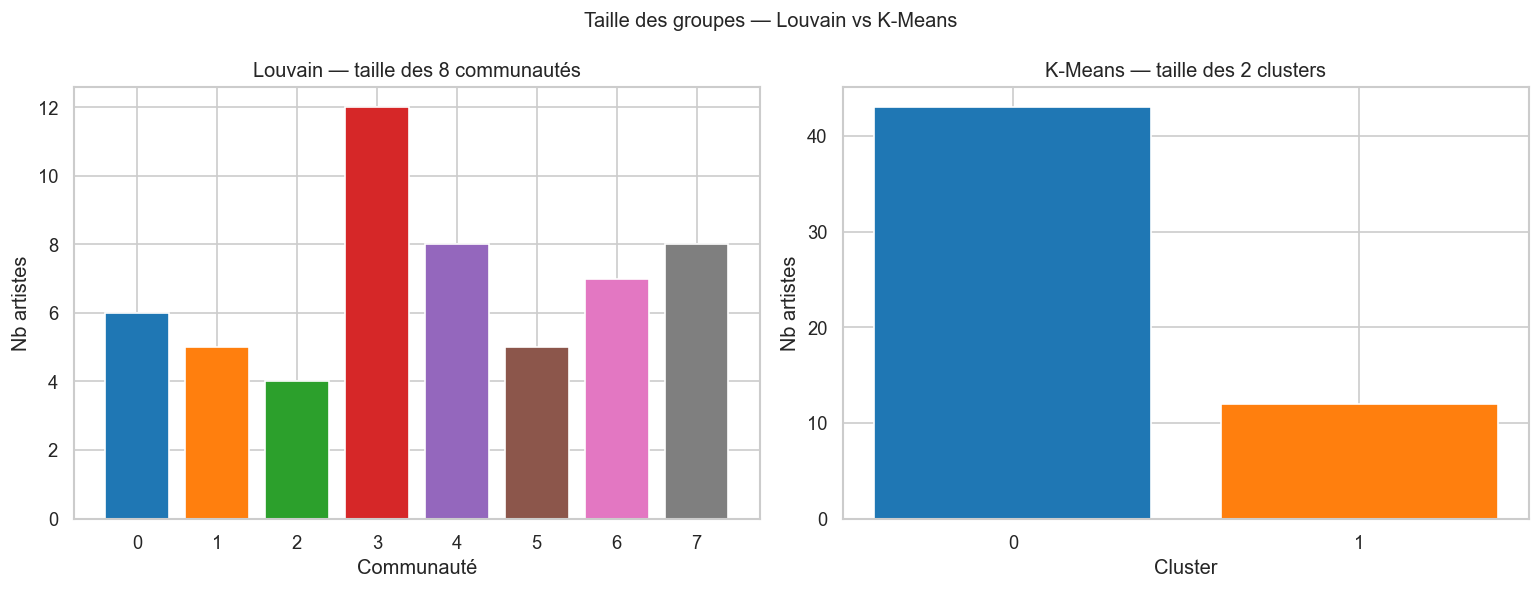

In [32]:
# Visualisation comparative : taille des groupes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

louvain_sizes = pd.Series(louvain_partition).value_counts().sort_index()
kmeans_sizes  = pd.Series(kmeans_labels).value_counts().sort_index()

axes[0].bar(louvain_sizes.index.astype(str), louvain_sizes.values,
            color=sns.color_palette('tab10', n_communities))
axes[0].set_title(f'Louvain — taille des {n_communities} communautés')
axes[0].set_xlabel('Communauté')
axes[0].set_ylabel('Nb artistes')

axes[1].bar(kmeans_sizes.index.astype(str), kmeans_sizes.values,
            color=sns.color_palette('tab10', BEST_K))
axes[1].set_title(f'K-Means — taille des {BEST_K} clusters')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Nb artistes')

plt.suptitle('Taille des groupes — Louvain vs K-Means', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fe_cluster_sizes.png', bbox_inches='tight')
plt.show()

## 11. Sauvegarde des artefacts

In [33]:
# Arêtes du graphe filtré
edges_out = pd.DataFrame(
    [(u, v, d['weight']) for u, v, d in G.edges(data=True)],
    columns=['source', 'target', 'weight']
)
edges_out.to_csv(DATA_DIR / 'graph_edges.csv', index=False)
print(f'graph_edges.csv       : {len(edges_out):,} arêtes')

# Features de nœuds
node_features_out = node_features[['artist'] + NUM_FEATS + ['louvain_community', 'node2vec_cluster']]
node_features_out.to_csv(DATA_DIR / 'node_features.csv', index=False)
print(f'node_features.csv     : {len(node_features_out):,} nœuds × {len(node_features_out.columns)} colonnes')

# Embeddings Node2Vec
emb_cols = [f'emb_{i}' for i in range(NODE2VEC_DIM)]
emb_df   = pd.DataFrame(embeddings, columns=emb_cols)
emb_df.insert(0, 'artist', NODES)
emb_df.to_csv(DATA_DIR / 'node_embeddings.csv', index=False)
print(f'node_embeddings.csv   : {len(emb_df):,} nœuds × {NODE2VEC_DIM} dimensions')

# Labels par artiste
labels_df = pd.DataFrame({
    'artist': NODES,
    'louvain_community': [louvain_partition.get(n, -1) for n in NODES],
    'node2vec_cluster':  kmeans_labels.tolist(),
})
labels_df.to_csv(DATA_DIR / 'node_labels.csv', index=False)
print(f'node_labels.csv       : {len(labels_df):,} nœuds')

print('\nSauvegarde OK.')

graph_edges.csv       : 64 arêtes
node_features.csv     : 55 nœuds × 11 colonnes
node_embeddings.csv   : 55 nœuds × 32 dimensions
node_labels.csv       : 55 nœuds

Sauvegarde OK.


## 12. Synthèse des choix de feature engineering

### Transformations retenues

| Transformation | Justification |
|---|---|
| Filtrage arêtes `weight ≥ 2` | Supprime le bruit (featings isolés) tout en conservant les liens significatifs |
| Composante connexe principale | Garantit un graphe connexe, requis pour Louvain et les random walks |
| Features de nœuds (degree, certifs, etc.) | Enrichit les nœuds avec du contexte métier pour l'analyse des communautés |
| Node2Vec `q=0.5` (BFS-biaisé) | Favorise l'exploration locale → capture mieux les communautés que DFS pur |
| `TruncatedSVD` à 32 dimensions | Réduit la matrice de co-occurrence dense en espace compact interprétable |
| `RobustScaler` avant UMAP | Insensible aux outliers des features `total_certifs` / `weighted_degree` |

### Transformations testées mais non retenues

| Transformation | Raison du rejet |
|---|---|
| Filtre seuil=1 (aucun filtre) | Trop de bruit, graphe trop sparse, communautés éclatées |
| Filtre seuil=3 ou 5 | Perd trop de connexions réelles, graphe trop petit |
| PCA sur features nœuds | Perte d'interprétabilité sans gain significatif en clustering |
| Node2Vec `q=1` (marche uniforme) | Moins sensible aux communautés locales qu'avec `q=0.5` |
| Node2Vec `q=2` (DFS-biaisé) | Capture des structures globales mais perd la cohérence locale |
| `dim=64` pour SVD | Variance expliquée marginalement supérieure, coût computationnel ↑ |
| Girvan-Newman | Trop lent sur ce graphe (O(mn²)), résultats similaires à Louvain |

### Conclusion

**Louvain** est recommandé comme algorithme principal : il maximise directement la modularité (critère naturel pour la détection de communautés musicales) et ne requiert pas de choisir $k$.  
**Node2Vec + K-Means** constitue une approche complémentaire utile si on souhaite intégrer des features de nœuds dans le clustering (en concaténant embeddings + features avant K-Means).